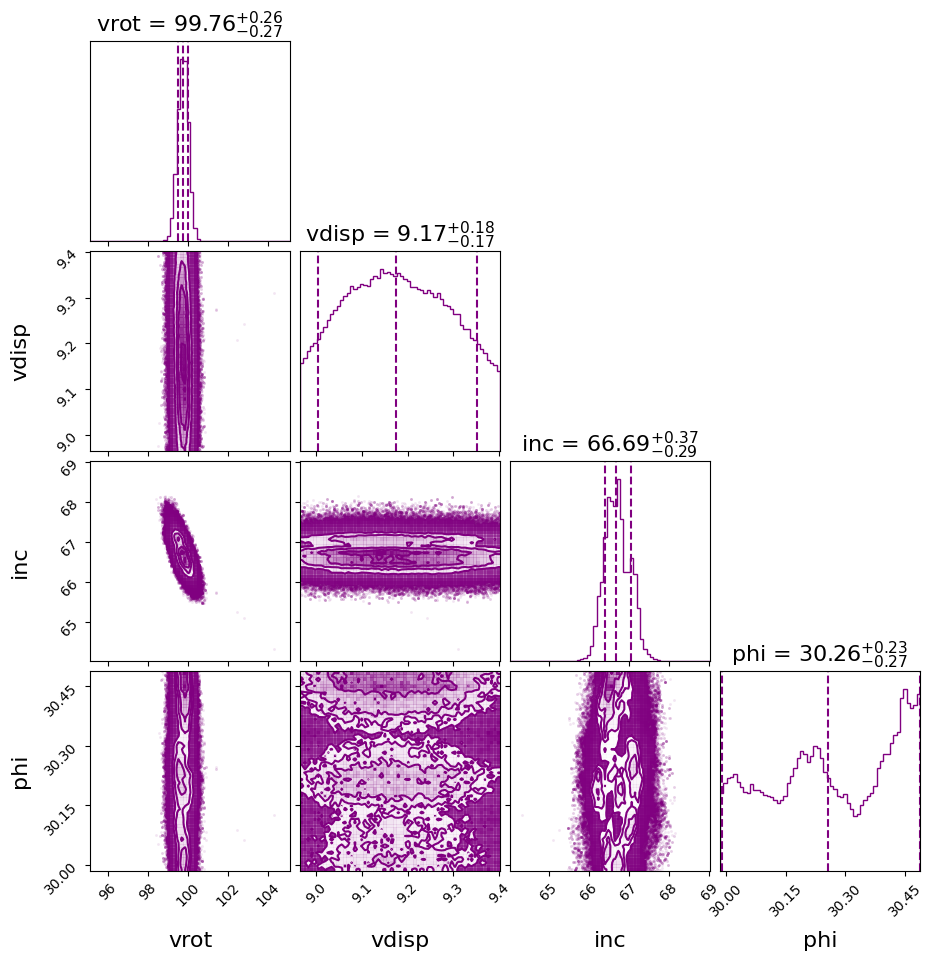

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import corner
import emcee
import os

samples = np.load("/home/user/THESIS/new_tests_single/new_tests_emcee_single/CGal_4_70_0.01_emcee_single_E_8000_samples.npy")
model = "CGal_4_70_0.01_emcee_single_E_8000"

#samples = np.load("/home/user/THESIS/new_tests_single/new_tests_emcee_single/CGal_4_70_0.01_emcee_single_C_8000_samples.npy")
#model = "CGal_4_70_0.01_emcee_single_C_8000"


labels = ["vrot", "vdisp", "inc", "phi"]

# If samples are saved as (nsteps, nwalkers, ndim), flatten them
if samples.ndim == 3:
    flat_samples = samples[3000:].reshape(-1, samples.shape[-1])
else:
    flat_samples = samples[3000:]

means = np.mean(flat_samples, axis=0)
stds = np.std(flat_samples, axis=0)
ranges = [(mean - std, mean + std) for mean, std in zip(means, stds)]
quantiles = [0.16, 0.50, 0.84]

fig2 = corner.corner(
    flat_samples,
    bins=60,
    show_titles=True,
    title_kwargs={"fontsize": 16},
    label_kwargs={"fontsize": 16},
    quantiles=quantiles,
    tick_params={"labelsize": 14},
    labels=labels,
    color='purple',
    plot_datapoints=True,
    range=ranges
)
plt.show()

fig2.savefig(f'/home/user/THESIS/new_tests_single/new_tests_emcee_single_q/{model}_corner.pdf',bbox_inches='tight')